<a href="https://colab.research.google.com/github/SNEHAL-KASHYAP/nsl-kdd-deep-learning-ids/blob/main/NSL_KDD_DNN_IDS_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 - INSTALL / IMPORT DEPENDENCIES
# ============================================================

!pip -q install tensorflow scikit-learn pandas numpy matplotlib seaborn requests

import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import requests

import tensorflow as tf

from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


In [ ]:
# ============================================================
# CELL 2 - REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Make TensorFlow behavior as deterministic as practical
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
# ============================================================
# CELL 3 - DOWNLOAD NSL-KDD DATASET
# ============================================================

DATA_DIR = "/content/nsl_kdd"

os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

TRAIN_PATH = os.path.join(DATA_DIR, "KDDTrain+.txt")
TEST_PATH  = os.path.join(DATA_DIR, "KDDTest+.txt")


def download_file(url, output_path):
    response = requests.get(url, timeout=60)
    response.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded: {output_path}")
    print(f"Size: {os.path.getsize(output_path) / (1024 * 1024):.2f} MB")


if not os.path.exists(TRAIN_PATH):
    download_file(TRAIN_URL, TRAIN_PATH)
else:
    print("Training file already exists.")

if not os.path.exists(TEST_PATH):
    download_file(TEST_URL, TEST_PATH)
else:
    print("Testing file already exists.")

Downloaded: /content/nsl_kdd/KDDTrain+.txt
Size: 18.22 MB
Downloaded: /content/nsl_kdd/KDDTest+.txt
Size: 3.28 MB


In [ ]:
# ============================================================
# CELL 4 - NSL-KDD COLUMN NAMES
# ============================================================

FEATURE_COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

TARGET_COLUMN = "label"
DIFFICULTY_COLUMN = "difficulty"

ALL_COLUMNS = FEATURE_COLUMNS + [
    TARGET_COLUMN,
    DIFFICULTY_COLUMN
]

print("Number of input features:", len(FEATURE_COLUMNS))
print("Total columns:", len(ALL_COLUMNS))

Number of input features: 41
Total columns: 43


In [ ]:
# ============================================================
# CELL 5 - LOAD DATASETS
# ============================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    names=ALL_COLUMNS
)

test_df = pd.read_csv(
    TEST_PATH,
    names=ALL_COLUMNS
)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

display(train_df.head())

Training shape: (125973, 43)
Testing shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
# ============================================================
# CELL 6 - INSPECT ATTACK LABELS
# ============================================================

print("Training attack labels:")
print(train_df[TARGET_COLUMN].value_counts())

print("\nTesting attack labels:")
print(test_df[TARGET_COLUMN].value_counts())

Training attack labels:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Testing attack labels:
label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
por

In [ ]:
# ============================================================
# ATTACK CATEGORY MAPPING
# ============================================================

ATTACK_CATEGORY = {
    # Normal
    "normal": "Normal",

    # -------------------------
    # DoS Attacks
    # -------------------------
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "mailbomb": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",

    # -------------------------
    # Probe Attacks
    # -------------------------
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",
    "mscan": "Probe",
    "saint": "Probe",

    # -------------------------
    # R2L Attacks
    # -------------------------
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",
    "named": "R2L",
    "sendmail": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpgetattack": "R2L",
    "snmpguess": "R2L",
    "worm": "R2L",

    # -------------------------
    # U2R Attacks
    # -------------------------
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",
    "httptunnel": "U2R",
    "ps": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R"
}


def map_attack_category(label):
    """
    Convert individual attack labels into the four
    major attack categories used by the IDS.
    """

    # Convert to string and remove unwanted spaces
    label = str(label).strip().lower()

    if label not in ATTACK_CATEGORY:
        raise ValueError(
            f"Unknown attack label encountered: {label}"
        )

    return ATTACK_CATEGORY[label]


# ============================================================
# APPLY MAPPING
# ============================================================

test_df["attack_category"] = test_df[TARGET_COLUMN].apply(
    map_attack_category
)

train_df["attack_category"] = train_df[TARGET_COLUMN].apply(
    map_attack_category
)

print("Attack category mapping completed successfully!")

print("\nTraining categories:")
print(train_df["attack_category"].value_counts())

print("\nTesting categories:")
print(test_df["attack_category"].value_counts())

Attack category mapping completed successfully!

Training categories:
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Testing categories:
attack_category
Normal    9711
DoS       7458
R2L       2754
Probe     2421
U2R        200
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 8 - SEPARATE FEATURES AND TARGETS
# ============================================================

X_train_raw = train_df[FEATURE_COLUMNS].copy()
X_test_raw = test_df[FEATURE_COLUMNS].copy()

y_train_binary = (
    train_df["attack_category"] != "Normal"
).astype(int)

y_test_binary = (
    test_df["attack_category"] != "Normal"
).astype(int)


CLASS_NAMES = [
    "Normal",
    "DoS",
    "Probe",
    "R2L",
    "U2R"
]

class_to_index = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

y_train_multi = train_df["attack_category"].map(class_to_index).values
y_test_multi = test_df["attack_category"].map(class_to_index).values


print("X_train:", X_train_raw.shape)
print("X_test :", X_test_raw.shape)

print("\nBinary labels:")
print(np.bincount(y_train_binary))

print("\nMulti-class labels:")
print(np.bincount(y_train_multi))

X_train: (125973, 41)
X_test : (22544, 41)

Binary labels:
[67343 58630]

Multi-class labels:
[67343 45927 11656   995    52]


In [ ]:
# ============================================================
# CELL 9 - CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

CATEGORICAL_COLUMNS = [
    "protocol_type",
    "service",
    "flag"
]

NUMERICAL_COLUMNS = [
    col for col in FEATURE_COLUMNS
    if col not in CATEGORICAL_COLUMNS
]

print("Categorical features:")
print(CATEGORICAL_COLUMNS)

print("\nNumber of numerical features:")
print(len(NUMERICAL_COLUMNS))

Categorical features:
['protocol_type', 'service', 'flag']

Number of numerical features:
38


In [ ]:
# ============================================================
# CELL 10 - PREPROCESSING
# ============================================================

# ------------------------------------------------------------
# One-Hot Encoder
# ------------------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train_raw[CATEGORICAL_COLUMNS]
)

X_test_cat = encoder.transform(
    X_test_raw[CATEGORICAL_COLUMNS]
)


# ------------------------------------------------------------
# StandardScaler
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train_raw[NUMERICAL_COLUMNS]
)

X_test_num = scaler.transform(
    X_test_raw[NUMERICAL_COLUMNS]
)


# ------------------------------------------------------------
# Combine numerical + categorical features
# ------------------------------------------------------------

X_train = np.hstack([
    X_train_num,
    X_train_cat
])

X_test = np.hstack([
    X_test_num,
    X_test_cat
])


print("Encoded categorical dimensions:",
      X_train_cat.shape[1])

print("Numerical dimensions:",
      X_train_num.shape[1])

print("Final training feature matrix:",
      X_train.shape)

print("Final testing feature matrix:",
      X_test.shape)

Encoded categorical dimensions: 84
Numerical dimensions: 38
Final training feature matrix: (125973, 122)
Final testing feature matrix: (22544, 122)


In [ ]:
# ============================================================
# OPTIONAL - L2 NORMALIZATION
# ============================================================

from sklearn.preprocessing import normalize

X_train_l2 = normalize(
    X_train,
    norm="l2",
    axis=1
)

X_test_l2 = normalize(
    X_test,
    norm="l2",
    axis=1
)

print("L2-normalized training shape:", X_train_l2.shape)
print("L2-normalized testing shape :", X_test_l2.shape)

L2-normalized training shape: (125973, 122)
L2-normalized testing shape : (22544, 122)


In [ ]:
X_train
X_test

array([[-0.11024922, -0.00776224, -0.00491864, ...,  0.        ,
         0.        ,  0.        ],
       [-0.11024922, -0.00776224, -0.00491864, ...,  0.        ,
         0.        ,  0.        ],
       [-0.10948132, -0.0055506 , -0.00491864, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.11024922,  0.00152858, -0.00285113, ...,  0.        ,
         1.        ,  0.        ],
       [-0.11024922, -0.00775509, -0.0049082 , ...,  0.        ,
         1.        ,  0.        ],
       [-0.11024922, -0.00776224, -0.00491864, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
# ============================================================
# CELL 12 - DNN MODEL
# ============================================================

def build_dnn(
    input_dim,
    output_units,
    output_activation,
    learning_rate=0.001
):

    model = tf.keras.Sequential(
        name="NSL_KDD_DNN"
    )

    # Input layer
    model.add(
        tf.keras.layers.Input(
            shape=(input_dim,)
        )
    )

    # --------------------------------------------------------
    # Hidden Layer 1
    # --------------------------------------------------------
    model.add(
        tf.keras.layers.Dense(
            1024,
            activation=None,
            kernel_initializer="he_normal"
        )
    )

    model.add(
        tf.keras.layers.BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation("relu")
    )

    model.add(
        tf.keras.layers.Dropout(0.01)
    )

    # --------------------------------------------------------
    # Hidden Layer 2
    # --------------------------------------------------------
    model.add(
        tf.keras.layers.Dense(
            1024,
            activation=None,
            kernel_initializer="he_normal"
        )
    )

    model.add(
        tf.keras.layers.BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation("relu")
    )

    model.add(
        tf.keras.layers.Dropout(0.01)
    )

    # --------------------------------------------------------
    # Hidden Layer 3
    # --------------------------------------------------------
    model.add(
        tf.keras.layers.Dense(
            1024,
            activation=None,
            kernel_initializer="he_normal"
        )
    )

    model.add(
        tf.keras.layers.BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation("relu")
    )

    model.add(
        tf.keras.layers.Dropout(0.01)
    )

    # --------------------------------------------------------
    # Hidden Layer 4
    # --------------------------------------------------------
    model.add(
        tf.keras.layers.Dense(
            1024,
            activation=None,
            kernel_initializer="he_normal"
        )
    )

    model.add(
        tf.keras.layers.BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation("relu")
    )

    model.add(
        tf.keras.layers.Dropout(0.01)
    )

    # --------------------------------------------------------
    # Hidden Layer 5
    # --------------------------------------------------------
    model.add(
        tf.keras.layers.Dense(
            1024,
            activation=None,
            kernel_initializer="he_normal"
        )
    )

    model.add(
        tf.keras.layers.BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation("relu")
    )

    model.add(
        tf.keras.layers.Dropout(0.01)
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------
    model.add(
        tf.keras.layers.Dense(
            output_units,
            activation=output_activation
        )
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------
    if output_units == 1:
        loss = "binary_crossentropy"
    else:
        loss = "sparse_categorical_crossentropy"

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    return model

In [ ]:
# ============================================================
# CELL 13 - BINARY CLASSIFICATION MODEL
# ============================================================

binary_model = build_dnn(
    input_dim=X_train.shape[1],
    output_units=1,
    output_activation="sigmoid",
    learning_rate=0.001
)

binary_model.summary()

Model: "NSL_KDD_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       125,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,345,857 (16.58 MB)

 Trainable params: 4,335,617 (16.54 MB)

 Non-trainable params: 10,240 (40.00 KB)

In [ ]:
# ============================================================
# CELL 14 - TRAINING CALLBACKS
# ============================================================

binary_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# ============================================================
# CELL 15 - TRAIN BINARY DNN
# ============================================================

EPOCHS = 50
BATCH_SIZE = 256

binary_history = binary_model.fit(
    X_train,
    y_train_binary.values,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=binary_callbacks,
    verbose=1,
    shuffle=True
)

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 96s 244ms/step - accuracy: 0.9927 - loss: 0.0197 - val_accuracy: 0.9921 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 95s 241ms/step - accuracy: 0.9939 - loss: 0.0165 - val_accuracy: 0.9912 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 147s 254ms/step - accuracy: 0.9947 - loss: 0.0147 - val_accuracy: 0.9931 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 141s 251ms/step - accuracy: 0.9950 - loss: 0.0131 - val_accuracy: 0.9933 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 95s 240ms/step - accuracy: 0.9953 - loss: 0.0127 - val_accuracy: 0.9913 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 146s 249ms/step - accuracy: 0.9956 - loss: 0.0120 - val_accuracy: 0.9937 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 137s 236ms/step - accuracy:

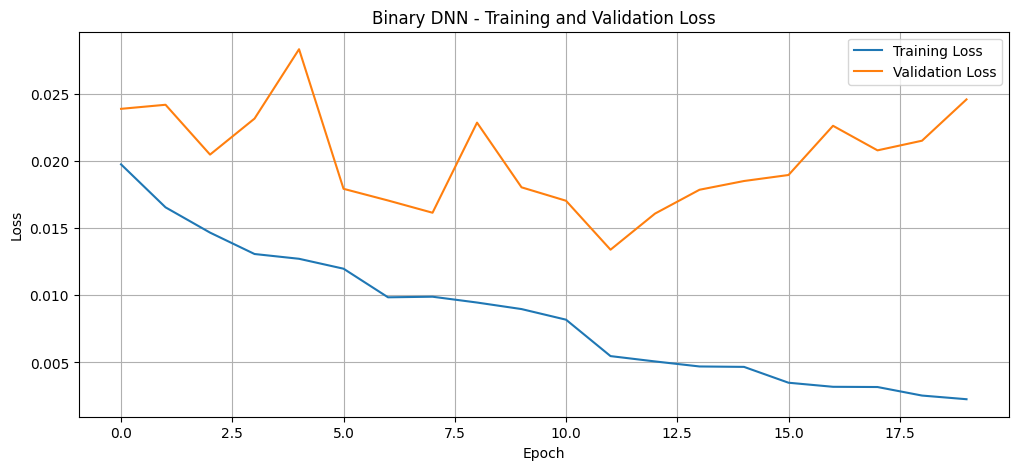

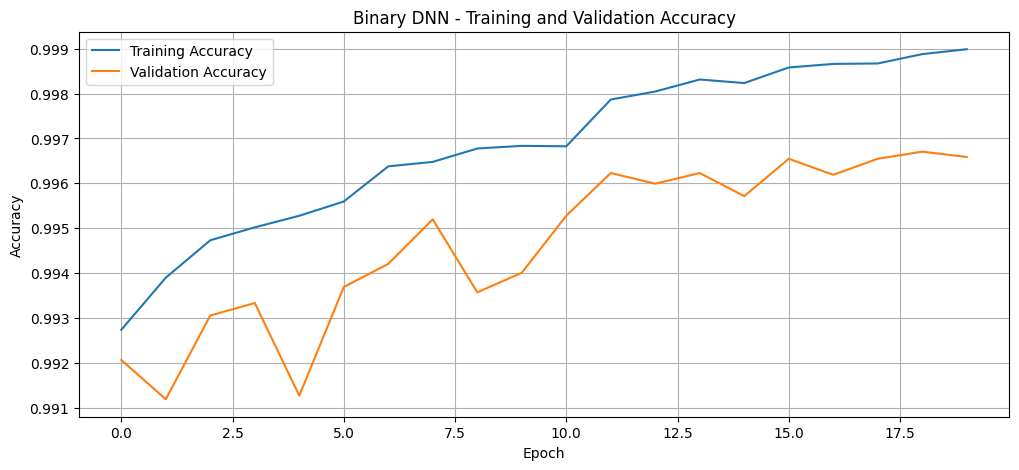

In [ ]:
# ============================================================
# CELL 16 - TRAINING / VALIDATION CURVES
# ============================================================

history = binary_history.history

plt.figure(figsize=(12, 5))

plt.plot(
    history["loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Binary DNN - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Binary DNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CELL 17 - BINARY PREDICTIONS
# ============================================================

binary_probabilities = binary_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
).ravel()

binary_predictions = (
    binary_probabilities >= 0.5
).astype(int)

y_true_binary = y_test_binary.values

print("Prediction shape:", binary_predictions.shape)

89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step
Prediction shape: (22544,)


In [ ]:
# ============================================================
# CELL 18 - BINARY METRICS
# ============================================================

accuracy = accuracy_score(
    y_true_binary,
    binary_predictions
)

precision = precision_score(
    y_true_binary,
    binary_predictions,
    zero_division=0
)

recall = recall_score(
    y_true_binary,
    binary_predictions,
    zero_division=0
)

f1 = f1_score(
    y_true_binary,
    binary_predictions,
    zero_division=0
)

cm = confusion_matrix(
    y_true_binary,
    binary_predictions
)

tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0


print("=" * 60)
print("BINARY IDS PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall/TPR: {recall:.4f}")
print(f"FPR       : {fpr:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true_binary,
        binary_predictions,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

BINARY IDS PERFORMANCE
Accuracy  : 0.7951
Precision : 0.9625
Recall/TPR: 0.6659
FPR       : 0.0343
F1 Score  : 0.7872

Confusion Matrix:
[[9378  333]
 [4287 8546]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.80      9711
      Attack       0.96      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.82      0.82      0.79     22544
weighted avg       0.84      0.80      0.79     22544



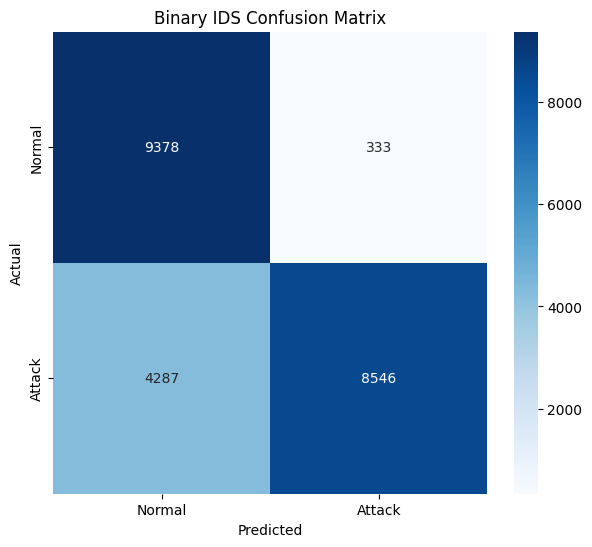

In [ ]:
# ============================================================
# CELL 19 - BINARY CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary IDS Confusion Matrix")

plt.show()

Binary ROC-AUC: 0.8652


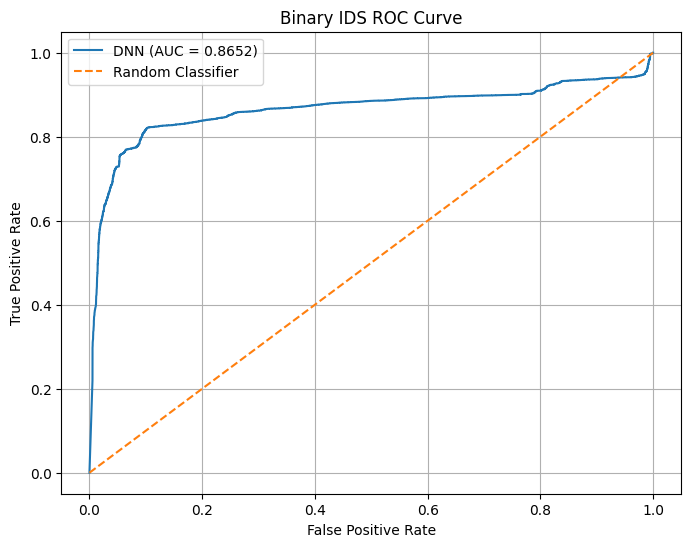

In [ ]:
# ============================================================
# CELL 20 - BINARY ROC CURVE
# ============================================================

fpr_curve, tpr_curve, thresholds = roc_curve(
    y_true_binary,
    binary_probabilities
)

binary_auc = auc(
    fpr_curve,
    tpr_curve
)

print(f"Binary ROC-AUC: {binary_auc:.4f}")


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_curve,
    tpr_curve,
    label=f"DNN (AUC = {binary_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary IDS ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CELL 21 - MULTI-CLASS DNN
# ============================================================

multi_model = build_dnn(
    input_dim=X_train.shape[1],
    output_units=5,
    output_activation="softmax",
    learning_rate=0.001
)

multi_model.summary()

Model: "NSL_KDD_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1024)           │       125,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,349,957 (16.59 MB)

 Trainable params: 4,339,717 (16.55 MB)

 Non-trainable params: 10,240 (40.00 KB)

In [ ]:
# ============================================================
# CELL 22 - MULTI-CLASS CALLBACKS
# ============================================================

multi_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# ============================================================
# CELL 23 - TRAIN MULTI-CLASS DNN
# ============================================================

multi_history = multi_model.fit(
    X_train,
    y_train_multi,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=multi_callbacks,
    verbose=1,
    shuffle=True
)

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 100s 240ms/step - accuracy: 0.9845 - loss: 0.0530 - val_accuracy: 0.9894 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 96s 243ms/step - accuracy: 0.9921 - loss: 0.0227 - val_accuracy: 0.9892 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 145s 251ms/step - accuracy: 0.9932 - loss: 0.0198 - val_accuracy: 0.9893 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 137s 239ms/step - accuracy: 0.9939 - loss: 0.0181 - val_accuracy: 0.9909 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 141s 237ms/step - accuracy: 0.9945 - loss: 0.0156 - val_accuracy: 0.9941 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 142s 238ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9896 - val_loss: 0.0348 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 94s 240ms/step - accuracy

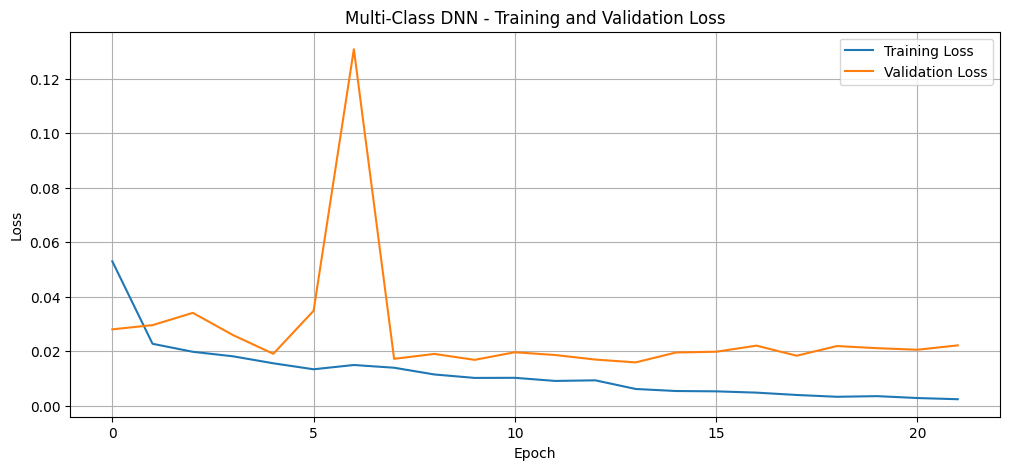

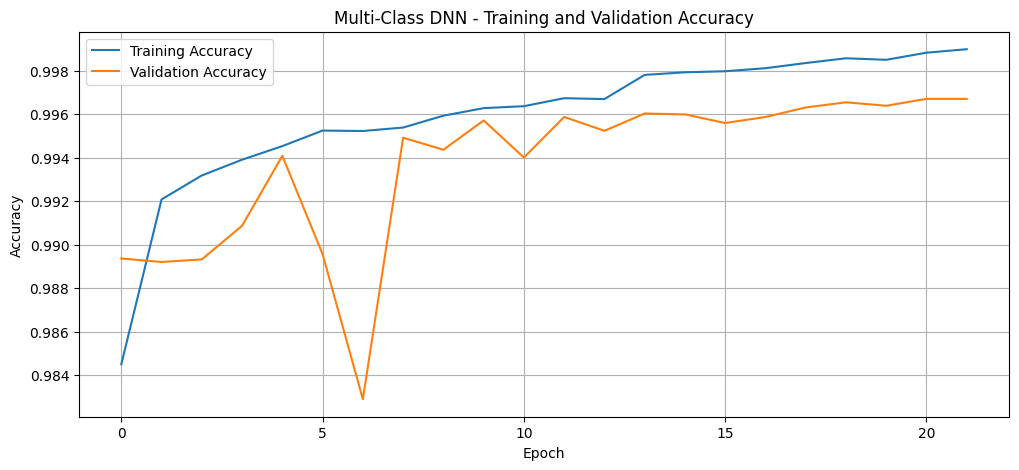

In [ ]:
# ============================================================
# CELL 24 - MULTI-CLASS TRAINING CURVES
# ============================================================

history_multi = multi_history.history

plt.figure(figsize=(12, 5))

plt.plot(
    history_multi["loss"],
    label="Training Loss"
)

plt.plot(
    history_multi["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-Class DNN - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    history_multi["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_multi["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multi-Class DNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CELL 25 - MULTI-CLASS PREDICTIONS
# ============================================================

multi_probabilities = multi_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

multi_predictions = np.argmax(
    multi_probabilities,
    axis=1
)

print("Prediction shape:", multi_predictions.shape)

89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step
Prediction shape: (22544,)


In [ ]:
# ============================================================
# CELL 26 - MULTI-CLASS METRICS
# ============================================================

y_true_multi = y_test_multi

multi_accuracy = accuracy_score(
    y_true_multi,
    multi_predictions
)

multi_precision = precision_score(
    y_true_multi,
    multi_predictions,
    average="macro",
    zero_division=0
)

multi_recall = recall_score(
    y_true_multi,
    multi_predictions,
    average="macro",
    zero_division=0
)

multi_f1 = f1_score(
    y_true_multi,
    multi_predictions,
    average="macro",
    zero_division=0
)


multi_cm = confusion_matrix(
    y_true_multi,
    multi_predictions,
    labels=np.arange(len(CLASS_NAMES))
)


print("=" * 60)
print("MULTI-CLASS IDS PERFORMANCE")
print("=" * 60)

print(f"Accuracy       : {multi_accuracy:.4f}")
print(f"Macro Precision: {multi_precision:.4f}")
print(f"Macro Recall   : {multi_recall:.4f}")
print(f"Macro F1       : {multi_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_true_multi,
        multi_predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

MULTI-CLASS IDS PERFORMANCE
Accuracy       : 0.7681
Macro Precision: 0.7213
Macro Recall   : 0.5082
Macro F1       : 0.5160

Classification Report:
              precision    recall  f1-score   support

      Normal       0.68      0.96      0.79      9711
         DoS       0.96      0.84      0.90      7458
       Probe       0.79      0.64      0.70      2421
         R2L       0.65      0.04      0.08      2754
         U2R       0.52      0.06      0.10       200

    accuracy                           0.77     22544
   macro avg       0.72      0.51      0.52     22544
weighted avg       0.78      0.77      0.73     22544



In [ ]:
# ============================================================
# CELL 27 - MULTI-CLASS FALSE POSITIVE RATES
# ============================================================

multi_fpr = {}

for i, class_name in enumerate(CLASS_NAMES):

    true_binary = (
        y_true_multi == i
    ).astype(int)

    pred_binary = (
        multi_predictions == i
    ).astype(int)

    cm_class = confusion_matrix(
        true_binary,
        pred_binary,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm_class.ravel()

    class_fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    multi_fpr[class_name] = class_fpr


print("False Positive Rate by class:")

for class_name, value in multi_fpr.items():
    print(f"{class_name:10s}: {value:.6f}")


macro_fpr = np.mean(
    list(multi_fpr.values())
)

print(f"\nMacro FPR: {macro_fpr:.6f}")

False Positive Rate by class:
Normal    : 0.351204
DoS       : 0.015776
Probe     : 0.020325
R2L       : 0.003284
U2R       : 0.000448

Macro FPR: 0.078207


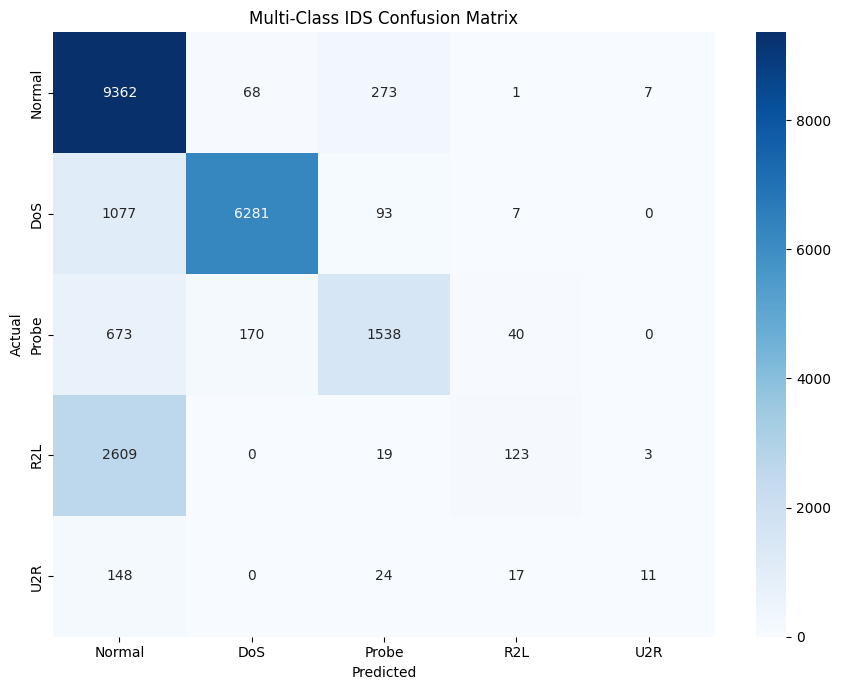

In [ ]:
# ============================================================
# CELL 28 - MULTI-CLASS CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    multi_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class IDS Confusion Matrix")

plt.tight_layout()
plt.show()

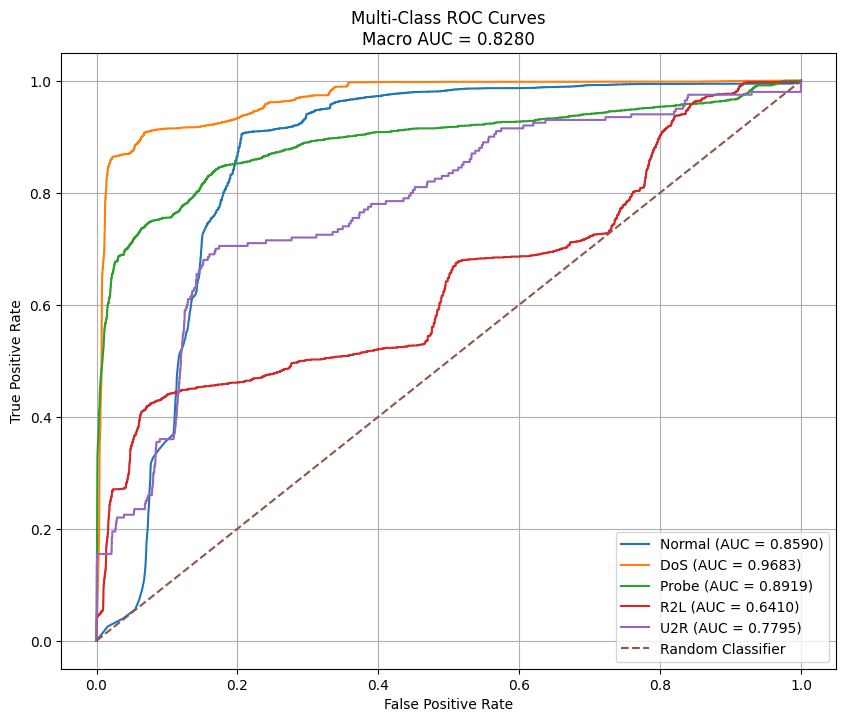

AUC per class:
Normal    : 0.8590
DoS       : 0.9683
Probe     : 0.8919
R2L       : 0.6410
U2R       : 0.7795

Macro AUC: 0.8280
Micro AUC: 0.9118


In [ ]:
# ============================================================
# CELL 29 - MULTI-CLASS ROC / AUC
# ============================================================

y_true_multi_onehot = label_binarize(
    y_true_multi,
    classes=np.arange(len(CLASS_NAMES))
)

roc_auc_per_class = {}

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASS_NAMES):

    fpr_i, tpr_i, _ = roc_curve(
        y_true_multi_onehot[:, i],
        multi_probabilities[:, i]
    )

    auc_i = auc(
        fpr_i,
        tpr_i
    )

    roc_auc_per_class[class_name] = auc_i

    plt.plot(
        fpr_i,
        tpr_i,
        label=f"{class_name} (AUC = {auc_i:.4f})"
    )


macro_auc = roc_auc_score(
    y_true_multi_onehot,
    multi_probabilities,
    average="macro",
    multi_class="ovr"
)

micro_auc = roc_auc_score(
    y_true_multi_onehot,
    multi_probabilities,
    average="micro"
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"Multi-Class ROC Curves\n"
    f"Macro AUC = {macro_auc:.4f}"
)

plt.legend()
plt.grid(True)
plt.show()


print("AUC per class:")

for class_name, value in roc_auc_per_class.items():
    print(f"{class_name:10s}: {value:.4f}")

print(f"\nMacro AUC: {macro_auc:.4f}")
print(f"Micro AUC: {micro_auc:.4f}")

In [ ]:
# ============================================================
# CELL 30 - FINAL RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / TPR",
        "FPR",
        "F1 Score",
        "ROC-AUC"
    ],

    "Binary": [
        accuracy,
        precision,
        recall,
        fpr,
        f1,
        binary_auc
    ],

    "Multi-Class": [
        multi_accuracy,
        multi_precision,
        multi_recall,
        macro_fpr,
        multi_f1,
        macro_auc
    ]
})

results["Binary"] = results["Binary"].round(4)
results["Multi-Class"] = results["Multi-Class"].round(4)

display(results)

,Metric,Binary,Multi-Class
0,Accuracy,0.7951,0.7681
1,Precision,0.9625,0.7213
2,Recall / TPR,0.6659,0.5082
3,FPR,0.0343,0.0782
4,F1 Score,0.7872,0.5160
5,ROC-AUC,0.8652,0.8280


In [ ]:
# ============================================================
# CELL 31 - SAVE TRAINED MODELS
# ============================================================

MODEL_DIR = "/content/models"

os.makedirs(MODEL_DIR, exist_ok=True)

binary_model_path = os.path.join(
    MODEL_DIR,
    "nsl_kdd_dnn_binary.keras"
)

multi_model_path = os.path.join(
    MODEL_DIR,
    "nsl_kdd_dnn_multiclass.keras"
)

binary_model.save(binary_model_path)
multi_model.save(multi_model_path)

print("Binary model saved to:")
print(binary_model_path)

print("\nMulti-class model saved to:")
print(multi_model_path)

Binary model saved to:
/content/models/nsl_kdd_dnn_binary.keras

Multi-class model saved to:
/content/models/nsl_kdd_dnn_multiclass.keras


In [ ]:
# ============================================================
# CELL 32 - SAVE PREPROCESSING OBJECTS
# ============================================================

import joblib

PREPROCESSOR_DIR = "/content/preprocessors"

os.makedirs(PREPROCESSOR_DIR, exist_ok=True)

joblib.dump(
    encoder,
    os.path.join(
        PREPROCESSOR_DIR,
        "onehot_encoder.pkl"
    )
)

joblib.dump(
    scaler,
    os.path.join(
        PREPROCESSOR_DIR,
        "standard_scaler.pkl"
    )
)

print("Preprocessors saved.")

Preprocessors saved.


In [ ]:
# ============================================================
# CELL 33 - PREDICTION FUNCTION
# ============================================================

def preprocess_new_data(dataframe):
    """
    Preprocess a dataframe containing the 41 NSL-KDD features.
    """

    categorical_data = encoder.transform(
        dataframe[CATEGORICAL_COLUMNS]
    )

    numerical_data = scaler.transform(
        dataframe[NUMERICAL_COLUMNS]
    )

    processed = np.hstack([
        numerical_data,
        categorical_data
    ])

    return processed


def predict_intrusion(dataframe):

    processed_data = preprocess_new_data(
        dataframe
    )

    probabilities = multi_model.predict(
        processed_data,
        verbose=0
    )

    predicted_indices = np.argmax(
        probabilities,
        axis=1
    )

    predictions = [
        CLASS_NAMES[index]
        for index in predicted_indices
    ]

    return predictions, probabilities

In [ ]:
# ============================================================
# CELL 34 - TEST PREDICTION FUNCTION
# ============================================================

sample = X_test_raw.iloc[:5].copy()

predictions, probabilities = predict_intrusion(
    sample
)

for i in range(len(predictions)):

    print(
        f"Sample {i + 1}: "
        f"Prediction = {predictions[i]}"
    )

    print(
        "Probabilities:",
        probabilities[i]
    )

    print()

Sample 1: Prediction = DoS
Probabilities: [1.0166313e-08 1.0000000e+00 3.4474880e-08 1.6097360e-08 1.8384945e-09]

Sample 2: Prediction = DoS
Probabilities: [1.5185019e-08 9.9999988e-01 1.6264534e-07 3.0587938e-08 3.6380843e-09]

Sample 3: Prediction = Normal
Probabilities: [1.0000000e+00 1.0456017e-10 5.2045017e-09 5.1042537e-10 1.5080843e-09]

Sample 4: Prediction = Probe
Probabilities: [3.3813072e-07 4.0945864e-07 9.9999273e-01 6.5744275e-06 3.9861865e-09]

Sample 5: Prediction = Normal
Probabilities: [9.9998772e-01 1.1194599e-06 4.1285443e-06 6.3596945e-06 6.9132949e-07]



In [ ]:
import os

print("Binary model exists:",
      os.path.exists("/content/models/nsl_kdd_dnn_binary.keras"))

print("Multi-class model exists:",
      os.path.exists("/content/models/nsl_kdd_dnn_multiclass.keras"))

print("\nModel files:")
for root, dirs, files in os.walk("/content/models"):
    for file in files:
        print(os.path.join(root, file))

Binary model exists: True
Multi-class model exists: True

Model files:
/content/models/nsl_kdd_dnn_binary.keras
/content/models/nsl_kdd_dnn_multiclass.keras


In [ ]:
import os

RESULTS_DIR = "/content/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results folder:", RESULTS_DIR)

Results folder: /content/results


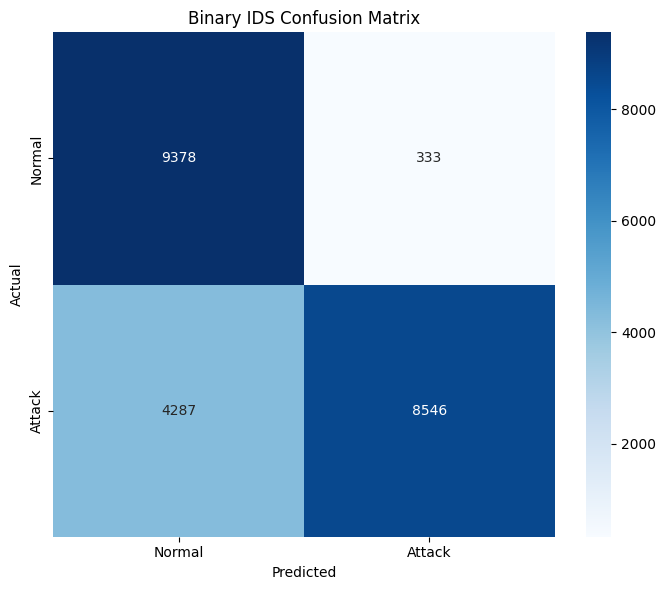

In [ ]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary IDS Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/results/confusion_matrix_binary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

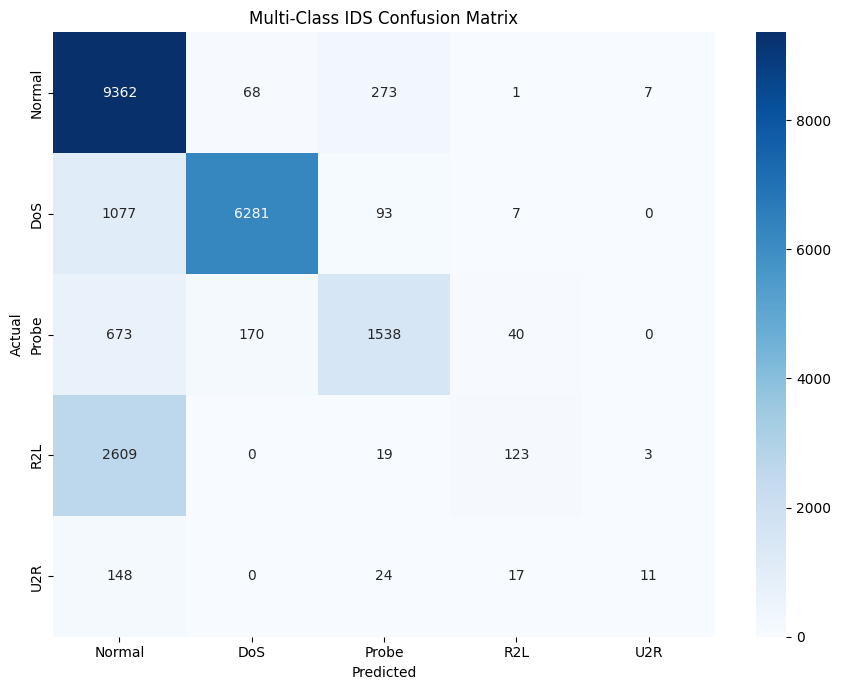

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    multi_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class IDS Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/results/confusion_matrix_multiclass.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

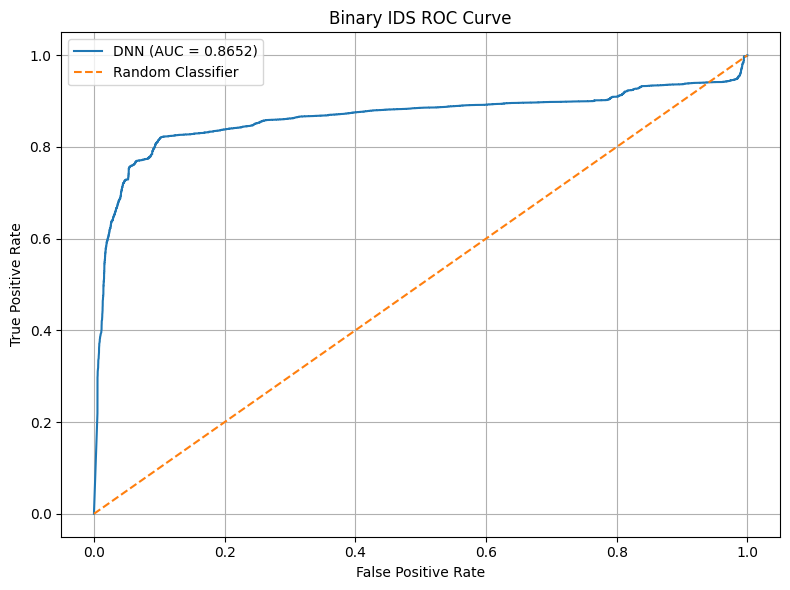

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_curve,
    tpr_curve,
    label=f"DNN (AUC = {binary_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary IDS ROC Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/results/roc_binary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

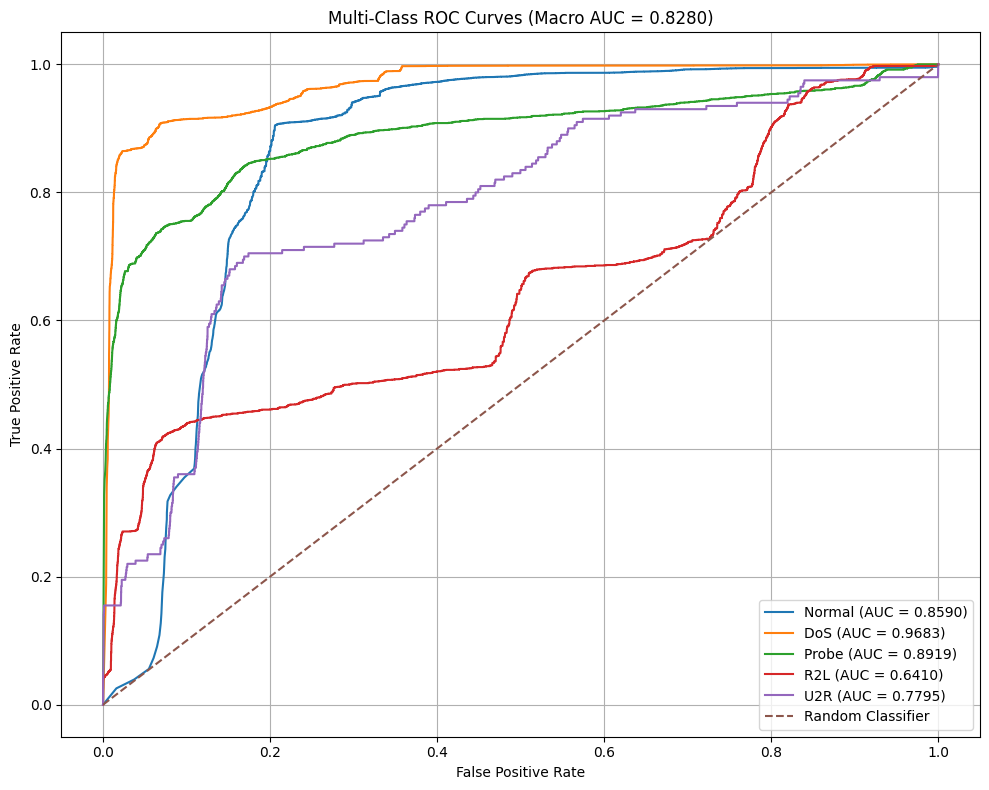

In [ ]:
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASS_NAMES):

    fpr_i, tpr_i, _ = roc_curve(
        y_true_multi_onehot[:, i],
        multi_probabilities[:, i]
    )

    auc_i = auc(fpr_i, tpr_i)

    plt.plot(
        fpr_i,
        tpr_i,
        label=f"{class_name} (AUC = {auc_i:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"Multi-Class ROC Curves (Macro AUC = {macro_auc:.4f})"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/results/roc_multiclass.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

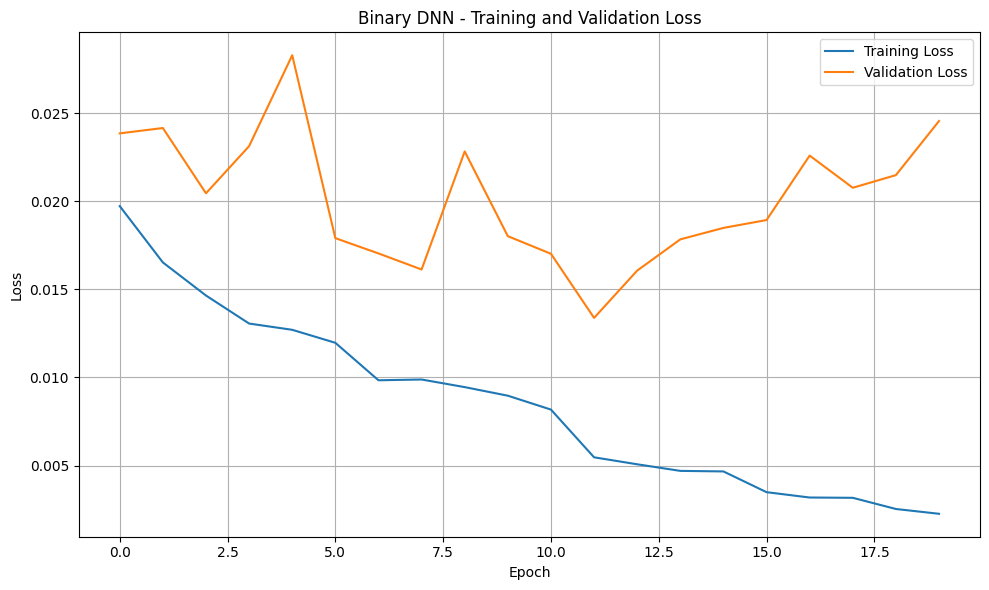

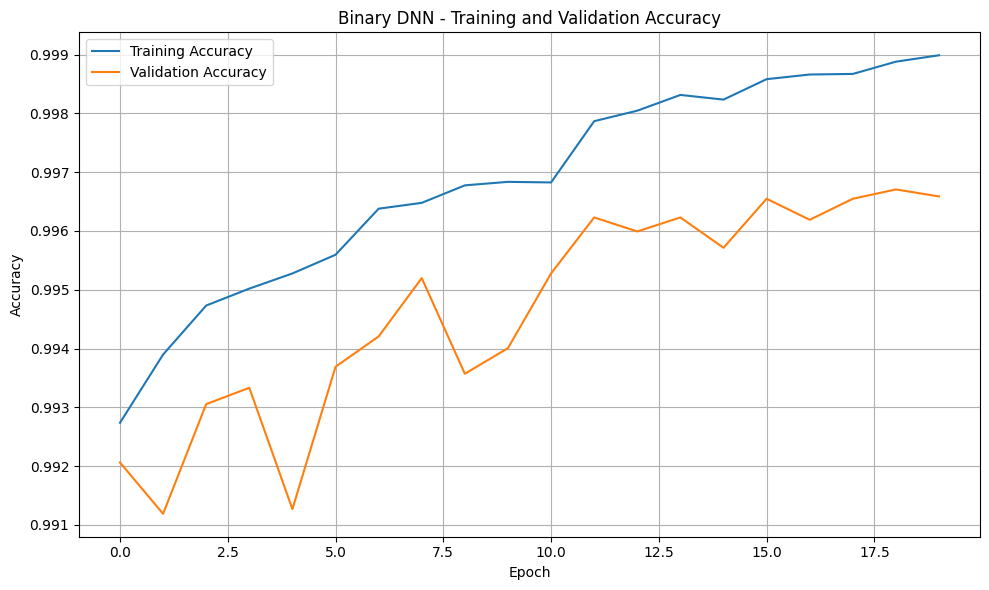

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    binary_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    binary_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Binary DNN - Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/results/binary_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    binary_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    binary_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Binary DNN - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/results/binary_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

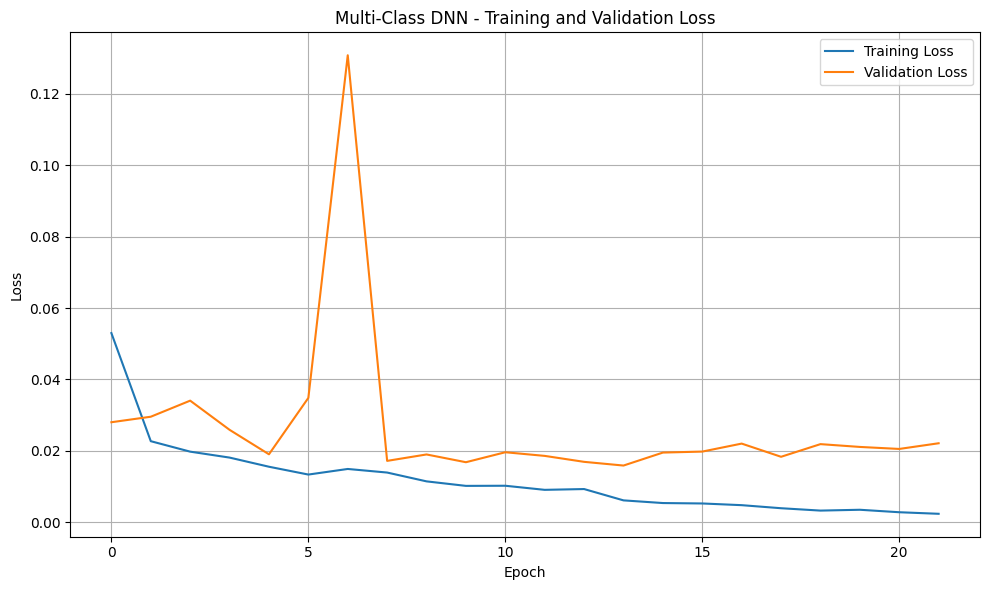

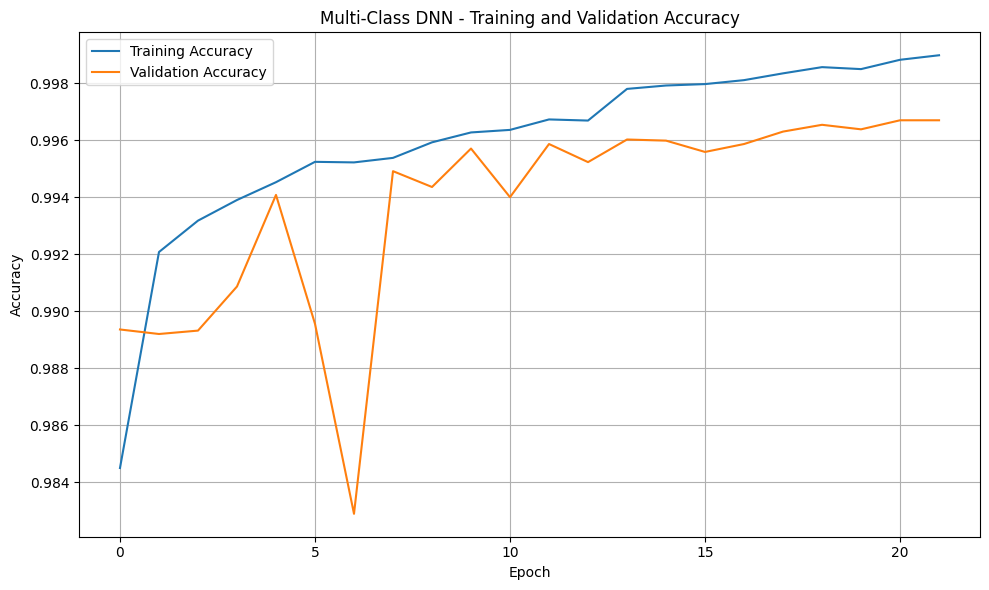

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    multi_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    multi_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-Class DNN - Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/results/multiclass_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    multi_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    multi_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multi-Class DNN - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/results/multiclass_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall_TPR",
        "FPR",
        "F1_Score",
        "ROC_AUC"
    ],

    "Binary": [
        accuracy,
        precision,
        recall,
        fpr,
        f1,
        binary_auc
    ],

    "Multi_Class": [
        multi_accuracy,
        multi_precision,
        multi_recall,
        macro_fpr,
        multi_f1,
        macro_auc
    ]
})

results["Binary"] = results["Binary"].round(4)
results["Multi_Class"] = results["Multi_Class"].round(4)

results.to_csv(
    "/content/results/metrics.csv",
    index=False
)

display(results)

,Metric,Binary,Multi_Class
0,Accuracy,0.7951,0.7681
1,Precision,0.9625,0.7213
2,Recall_TPR,0.6659,0.5082
3,FPR,0.0343,0.0782
4,F1_Score,0.7872,0.5160
5,ROC_AUC,0.8652,0.8280


In [ ]:
for root, dirs, files in os.walk("/content/results"):
    for file in files:
        print(os.path.join(root, file))

/content/results/multiclass_accuracy.png
/content/results/binary_accuracy.png
/content/results/roc_binary.png
/content/results/roc_multiclass.png
/content/results/metrics.csv
/content/results/multiclass_loss.png
/content/results/confusion_matrix_binary.png
/content/results/binary_loss.png
/content/results/confusion_matrix_multiclass.png


In [ ]:
# ============================================================
# STEP 45 - SAVE DETAILED CLASSIFICATION REPORTS
# ============================================================

binary_report = classification_report(
    y_true_binary,
    binary_predictions,
    target_names=["Normal", "Attack"],
    output_dict=True,
    zero_division=0
)

binary_report_df = pd.DataFrame(binary_report).transpose()

binary_report_df.to_csv(
    "/content/results/binary_classification_report.csv"
)


multi_report = classification_report(
    y_true_multi,
    multi_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

multi_report_df = pd.DataFrame(multi_report).transpose()

multi_report_df.to_csv(
    "/content/results/multiclass_classification_report.csv"
)


print("Binary classification report:")
display(binary_report_df.round(4))

print("\nMulti-class classification report:")
display(multi_report_df.round(4))

Binary classification report:


,precision,recall,f1-score,support
Normal,0.6863,0.9657,0.8024,9711.0000
Attack,0.9625,0.6659,0.7872,12833.0000
accuracy,0.7951,0.7951,0.7951,0.7951
macro avg,0.8244,0.8158,0.7948,22544.0000
weighted avg,0.8435,0.7951,0.7937,22544.0000



Multi-class classification report:


,precision,recall,f1-score,support
Normal,0.6750,0.9641,0.7941,9711.0000
DoS,0.9635,0.8422,0.8988,7458.0000
Probe,0.7899,0.6353,0.7042,2421.0000
R2L,0.6543,0.0447,0.0836,2754.0000
U2R,0.5238,0.0550,0.0995,200.0000
accuracy,0.7681,0.7681,0.7681,0.7681
macro avg,0.7213,0.5082,0.5160,22544.0000
weighted avg,0.7789,0.7681,0.7261,22544.0000


In [ ]:
# ============================================================
# STEP 46 - CLASS-WISE MULTI-CLASS PERFORMANCE
# ============================================================

class_metrics = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": precision_score(
        y_true_multi,
        multi_predictions,
        average=None,
        labels=np.arange(len(CLASS_NAMES)),
        zero_division=0
    ),
    "Recall": recall_score(
        y_true_multi,
        multi_predictions,
        average=None,
        labels=np.arange(len(CLASS_NAMES)),
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_true_multi,
        multi_predictions,
        average=None,
        labels=np.arange(len(CLASS_NAMES)),
        zero_division=0
    )
})

class_metrics = class_metrics.round(4)

display(class_metrics)

class_metrics.to_csv(
    "/content/results/class_wise_metrics.csv",
    index=False
)

,Class,Precision,Recall,F1 Score
0,Normal,0.6750,0.9641,0.7941
1,DoS,0.9635,0.8422,0.8988
2,Probe,0.7899,0.6353,0.7042
3,R2L,0.6543,0.0447,0.0836
4,U2R,0.5238,0.0550,0.0995


In [ ]:
# ============================================================
# STEP 47 - FINAL RESULTS FILE CHECK
# ============================================================

for root, dirs, files in os.walk("/content/results"):
    for file in sorted(files):
        print(os.path.join(root, file))

/content/results/binary_accuracy.png
/content/results/binary_classification_report.csv
/content/results/binary_loss.png
/content/results/class_wise_metrics.csv
/content/results/confusion_matrix_binary.png
/content/results/confusion_matrix_multiclass.png
/content/results/metrics.csv
/content/results/multiclass_accuracy.png
/content/results/multiclass_classification_report.csv
/content/results/multiclass_loss.png
/content/results/roc_binary.png
/content/results/roc_multiclass.png


In [ ]:
# ============================================================
# STEP 48 - CREATE GITHUB PROJECT STRUCTURE
# ============================================================

import os
import shutil

PROJECT_DIR = "/content/nsl-kdd-dnn-ids"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/src", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/preprocessors", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/results", exist_ok=True)

print("Project structure created successfully.")
print(PROJECT_DIR)

Project structure created successfully.
/content/nsl-kdd-dnn-ids


In [ ]:
# ============================================================
# STEP 49 - COPY TRAINED MODELS
# ============================================================

shutil.copy(
    "/content/models/nsl_kdd_dnn_binary.keras",
    f"{PROJECT_DIR}/models/nsl_kdd_dnn_binary.keras"
)

shutil.copy(
    "/content/models/nsl_kdd_dnn_multiclass.keras",
    f"{PROJECT_DIR}/models/nsl_kdd_dnn_multiclass.keras"
)

print("Both trained models copied successfully.")

Both trained models copied successfully.


In [ ]:
# ============================================================
# STEP 50 - COPY PREPROCESSORS
# ============================================================

shutil.copy(
    "/content/preprocessors/onehot_encoder.pkl",
    f"{PROJECT_DIR}/preprocessors/onehot_encoder.pkl"
)

shutil.copy(
    "/content/preprocessors/standard_scaler.pkl",
    f"{PROJECT_DIR}/preprocessors/standard_scaler.pkl"
)

print("Preprocessing files copied successfully.")

Preprocessing files copied successfully.


In [ ]:
# ============================================================
# STEP 51 - COPY RESULTS
# ============================================================

shutil.copytree(
    "/content/results",
    f"{PROJECT_DIR}/results",
    dirs_exist_ok=True
)

print("All results copied successfully.")

All results copied successfully.


In [ ]:
# ============================================================
# STEP 52 - FIND COLAB NOTEBOOK
# ============================================================

!find /content -maxdepth 2 -name "*.ipynb"

In [ ]:
# ============================================================
# NSL-KDD DATASET - DOWNLOAD AND LOAD
# ============================================================

import os
import pandas as pd
import requests

# Create dataset folder
os.makedirs("/content/nsl_kdd", exist_ok=True)

# Dataset URLs
train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
test_url  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

# File paths
train_path = "/content/nsl_kdd/KDDTrain+.txt"
test_path  = "/content/nsl_kdd/KDDTest+.txt"

# Download training dataset
response = requests.get(train_url)
response.raise_for_status()

with open(train_path, "wb") as f:
    f.write(response.content)

# Download testing dataset
response = requests.get(test_url)
response.raise_for_status()

with open(test_path, "wb") as f:
    f.write(response.content)

print("Dataset downloaded successfully!")
print()

# NSL-KDD has 41 traffic features + label + difficulty
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

# Load datasets
train_df = pd.read_csv(train_path, header=None, names=columns)
test_df = pd.read_csv(test_path, header=None, names=columns)

# Display information
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)
print()

print("First 5 rows of KDDTrain+:")
display(train_df.head())

print("\nAttack/Normal labels in training data:")
display(train_df["label"].value_counts().head(20))

Dataset downloaded successfully!

Training dataset shape: (125973, 43)
Testing dataset shape : (22544, 43)

First 5 rows of KDDTrain+:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21



Attack/Normal labels in training data:


,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'nsl_kdd', 'sample_data']


In [1]:
import os
print(os.listdir("/content"))

['.config', 'sample_data']
